# MD-GRTN Phase 2 — Multi-Period Input (Recent + Yesterday + 1-Week)
**Architecture:** MDAF with 3 BackNets → MAF → MGRC (dual adjacency, deeper GCN+GRU) → Spatial Transformer ×L → Temporal Transformer ×L

| Period | Window | Offset |
|--------|--------|--------|
| Recent | t-12 … t | 0 steps |
| Yesterday | same window, -288 steps | 288 × 5min = 24h |
| 1-week ago | same window, -2016 steps | 2016 × 5min = 7d |

> Benchmark to beat — MD-GRTN: MAE 13.114 | RMSE 22.623 | MAPE 8.471%

In [1]:
# Colab: dependencies already available
# !pip install torch numpy matplotlib -q
import torch, numpy as np
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())

PyTorch: 2.10.0+cu128
CUDA: True


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

class Config:
    # data
    data_path   = "/content/PEMS08.npz"   # <-- update path
    num_nodes   = 170
    in_features = 3               # flow, occupancy, speed
    seq_len     = 12              # 12 × 5min = 1hr input window
    pred_len    = 12
    feature_idx = 0               # predict flow

    # multi-period offsets (in time steps, 5-min intervals)
    offset_day  = 288             # 24h
    offset_week = 2016            # 7 days

    # model — deeper config
    d_model    = 128              # wider embedding
    n_heads    = 8
    num_layers = 4                # L spatial + L temporal transformer layers
    gru_layers = 4                # stacked GCN+GRU layers per sequence branch
    ff_mult    = 4                # feed-forward multiplier
    dropout    = 0.1

    # training
    batch_size  = 16              # smaller batch for deeper model
    lr          = 5e-4
    weight_decay= 1e-4
    epochs      = 100
    patience    = 15
    grad_clip   = 5.0
    train_ratio = 0.6
    val_ratio   = 0.2

cfg = Config()
print('Config loaded.')

Config loaded.


In [3]:
def load_pems08(cfg):
    raw  = np.load(cfg.data_path, allow_pickle=True)
    print('npz keys:', list(raw.keys()))
    data = raw['data'].astype(np.float32)          # (T, N, F)
    T, N, F = data.shape
    print(f'Shape: {data.shape}')

    # per-sensor, per-feature z-score  (avoids global scale masking sensor variance)
    mean = data.mean(axis=0, keepdims=True)        # (1, N, F)
    std  = data.std(axis=0,  keepdims=True) + 1e-8
    data = (data - mean) / std

    # ── distance adjacency ──
    for key in ('adjacency_matrix', 'adj_mx', 'adj'):
        if key in raw:
            A_dist = raw[key].astype(np.float32)
            print(f'Loaded A_dist from key "{key}", shape {A_dist.shape}')
            break
    else:
        print('No adjacency found — using identity.')
        A_dist = np.eye(N, dtype=np.float32)

    # row-normalize
    deg    = A_dist.sum(1, keepdims=True) + 1e-8
    A_dist = A_dist / deg

    return data, mean, std, A_dist


class MultiPeriodDataset(Dataset):
    """Returns (x_recent, x_day, x_week, y).
       Samples only where all three periods are valid (t >= offset_week + seq_len)."""
    def __init__(self, data, cfg, start, end):
        self.data     = torch.from_numpy(data)
        self.seq_len  = cfg.seq_len
        self.pred_len = cfg.pred_len
        self.feat_idx = cfg.feature_idx
        self.od       = cfg.offset_day
        self.ow       = cfg.offset_week
        # valid start index: need week-ago data available
        min_start = cfg.offset_week + cfg.seq_len
        self.indices  = [i for i in range(start + min_start, end - cfg.pred_len + 1)]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]
        S, P, fi = self.seq_len, self.pred_len, self.feat_idx

        x_rec  = self.data[t - S      : t]                   # (S, N, F)
        x_day  = self.data[t - S - self.od : t - self.od]    # (S, N, F)
        x_week = self.data[t - S - self.ow : t - self.ow]    # (S, N, F)
        y      = self.data[t : t + P, :, fi]                 # (P, N)
        return x_rec, x_day, x_week, y


def build_dataloaders(cfg):
    data, mean, std, A_dist = load_pems08(cfg)
    T  = len(data)
    t1 = int(T * cfg.train_ratio)
    t2 = int(T * (cfg.train_ratio + cfg.val_ratio))

    ds_tr = MultiPeriodDataset(data, cfg, 0,  t1)
    ds_va = MultiPeriodDataset(data, cfg, t1, t2)
    ds_te = MultiPeriodDataset(data, cfg, t2, T)

    kw = dict(batch_size=cfg.batch_size, num_workers=2, pin_memory=True)
    dl_tr = DataLoader(ds_tr, shuffle=True,  **kw)
    dl_va = DataLoader(ds_va, shuffle=False, **kw)
    dl_te = DataLoader(ds_te, shuffle=False, **kw)

    print(f'Train={len(ds_tr)} | Val={len(ds_va)} | Test={len(ds_te)} samples')
    return dl_tr, dl_va, dl_te, mean, std, A_dist

print('Dataset utilities ready.')

Dataset utilities ready.


In [4]:
# ═══════════════════════════════════════════════════
# MDAF: Multi-period Diffusion Attention Fusion
#   3 × BackNet (one per period) + MAF
# ═══════════════════════════════════════════════════

class BackNet(nn.Module):
    """Per-period MLP denoiser with residual connection."""
    def __init__(self, in_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, in_dim),
        )
        self.norm = nn.LayerNorm(in_dim)

    def forward(self, x):     # (B, S, N, F) → (B, S, N, F)
        return self.norm(x + self.net(x))


class MultiHeadAttentionFusion(nn.Module):
    """
    Project each cleaned sequence → d_model,
    dot-product attention over nodes,
    concat all periods → FC → (B, S, N, d_model).
    """
    def __init__(self, in_dim, d_model, n_heads, n_seqs, dropout=0.1):
        super().__init__()
        self.projs  = nn.ModuleList([nn.Linear(in_dim, d_model) for _ in range(n_seqs)])
        self.attns  = nn.ModuleList([
            nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
            for _ in range(n_seqs)
        ])
        self.fc_out = nn.Sequential(
            nn.Linear(d_model * n_seqs, d_model * 2),
            nn.GELU(),
            nn.Linear(d_model * 2, d_model),
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, seqs):   # list of (B,S,N,F) → (B,S,N,d)
        B, S, N, _ = seqs[0].shape
        projected = []
        for proj, attn, seq in zip(self.projs, self.attns, seqs):
            h  = proj(seq.reshape(B*S, N, -1))         # (B*S, N, d)
            h, _ = attn(h, h, h)                        # spatial attention over nodes
            projected.append(h.reshape(B, S, N, -1))
        fused = torch.cat(projected, dim=-1)            # (B, S, N, d*n_seqs)
        return self.norm(self.fc_out(fused))            # (B, S, N, d)


class MDAFModule(nn.Module):
    def __init__(self, in_features, d_model, n_heads, n_seqs=3, dropout=0.1):
        super().__init__()
        self.backnets = nn.ModuleList([BackNet(in_features, d_model, dropout) for _ in range(n_seqs)])
        self.maf      = MultiHeadAttentionFusion(in_features, d_model, n_heads, n_seqs, dropout)

    def forward(self, seqs):   # list of 3 × (B,S,N,F) → (B,S,N,d)
        cleaned = [bn(s) for bn, s in zip(self.backnets, seqs)]
        return self.maf(cleaned)

print('MDAF (3-period) defined.')

MDAF (3-period) defined.


In [5]:
# ═══════════════════════════════════════════════════
# MGRC: Multi-Graph Recurrent Convolution
#   Dual adjacency: A_dist (fixed) + A_dyna (learnable)
#   Concat → 2D Conv → A_F
#   Deeper stacked GCN + GRU layers
# ═══════════════════════════════════════════════════

class ChebGraphConv(nn.Module):
    """Chebyshev spectral GCN (K=2): captures 2-hop neighbourhoods."""
    def __init__(self, in_dim, out_dim, K=2):
        super().__init__()
        self.K    = K
        self.lins = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(K)])

    def forward(self, x, A):
        # x: (B,N,d), A: (N,N)
        out = self.lins[0](x)                 # K=0 term (identity)
        Ax  = torch.einsum('nm,bmd->bnd', A, x)
        out = out + self.lins[1](Ax)          # K=1 term
        return out


class GCN_GRU_Layer(nn.Module):
    """ChebGCN output → GRU cell, step-by-step over S."""
    def __init__(self, in_dim, hidden_dim, K=2):
        super().__init__()
        self.gcn  = ChebGraphConv(in_dim, hidden_dim, K)
        self.gru  = nn.GRUCell(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x_seq, A):   # (B,S,N,in) → (B,S,N,hid)
        B, S, N, _ = x_seq.shape
        h = torch.zeros(B*N, self.gru.hidden_size, device=x_seq.device)
        outs = []
        for t in range(S):
            x_t  = x_seq[:, t]                              # (B,N,d)
            g    = F.gelu(self.gcn(x_t, A))                 # (B,N,hid)
            h    = self.gru(g.reshape(B*N, -1), h)
            outs.append(self.norm(h).reshape(B, N, -1))
        return torch.stack(outs, dim=1)                      # (B,S,N,hid)


class MGRCModule(nn.Module):
    """
    Deeper MGRC:
      - A_dyna via node embedding outer-product
      - A_dist from data
      - Fused A_F via 2D Conv
      - num_layers stacked GCN+GRU
    """
    def __init__(self, in_dim, hidden_dim, num_nodes, num_layers=4, K=2, dropout=0.1):
        super().__init__()
        # learnable node embeddings for dynamic adjacency
        self.src_emb  = nn.Parameter(torch.randn(num_nodes, hidden_dim // 2))
        self.tgt_emb  = nn.Parameter(torch.randn(num_nodes, hidden_dim // 2))
        # fuse 2 adjacency matrices via 1×1 conv
        self.adj_conv = nn.Sequential(
            nn.Conv2d(2, 8, kernel_size=1), nn.ReLU(),
            nn.Conv2d(8, 1, kernel_size=1),
        )
        self.drop = nn.Dropout(dropout)
        # stacked layers
        dims = [in_dim] + [hidden_dim] * num_layers
        self.layers = nn.ModuleList([
            GCN_GRU_Layer(dims[i], dims[i+1], K) for i in range(num_layers)
        ])

    def get_fused_adj(self, A_dist):
        # dynamic adjacency
        A_dyna  = torch.softmax(self.src_emb @ self.tgt_emb.T / (self.src_emb.shape[1]**0.5), dim=-1)
        stacked = torch.stack([A_dist, A_dyna], dim=0).unsqueeze(0)  # (1,2,N,N)
        A_F     = self.adj_conv(stacked).squeeze(0).squeeze(0)        # (N,N)
        A_F     = F.relu(A_F)
        return A_F / (A_F.sum(-1, keepdim=True) + 1e-8)

    def forward(self, x, A_dist):   # (B,S,N,d) → (B,S,N,hid)
        A_F = self.get_fused_adj(A_dist)
        for layer in self.layers:
            x = self.drop(layer(x, A_F))
        return x

print('MGRC (ChebGCN, dual-adjacency, deeper) defined.')

MGRC (ChebGCN, dual-adjacency, deeper) defined.


In [6]:
# ═══════════════════════════════════════════════════
# Spatial & Temporal Transformer layers
# ═══════════════════════════════════════════════════

class TransformerBlock(nn.Module):
    """Generic transformer block — used for both spatial and temporal."""
    def __init__(self, d_model, n_heads, ff_mult=4, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * ff_mult),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * ff_mult, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):   # (B, L, d)
        h, _ = self.attn(x, x, x)
        x    = self.norm1(x + self.drop(h))
        return self.norm2(x + self.drop(self.ff(x)))


class SpatialTransformerLayer(nn.Module):
    def __init__(self, d_model, n_heads, ff_mult=4, dropout=0.1):
        super().__init__()
        self.blk = TransformerBlock(d_model, n_heads, ff_mult, dropout)
    def forward(self, x):        # (B,S,N,d) → (B,S,N,d)
        B, S, N, d = x.shape
        h = self.blk(x.reshape(B*S, N, d))
        return h.reshape(B, S, N, d)


class TemporalTransformerLayer(nn.Module):
    def __init__(self, d_model, n_heads, ff_mult=4, dropout=0.1):
        super().__init__()
        self.blk = TransformerBlock(d_model, n_heads, ff_mult, dropout)
    def forward(self, x):        # (B,S,N,d) → (B,S,N,d)
        B, S, N, d = x.shape
        h = self.blk(x.permute(0,2,1,3).reshape(B*N, S, d))
        return h.reshape(B, N, S, d).permute(0,2,1,3)

print('Transformer layers defined.')

Transformer layers defined.


In [7]:
# ═══════════════════════════════════════════════════
# Full MD-GRTN  (Phase 2 — 3 periods, deeper)
# ═══════════════════════════════════════════════════

class MDGRTN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        N  = cfg.num_nodes
        F  = cfg.in_features
        d  = cfg.d_model
        L  = cfg.num_layers
        h  = cfg.n_heads
        dr = cfg.dropout
        fm = cfg.ff_mult
        P  = cfg.pred_len
        S  = cfg.seq_len

        # 1. MDAF: 3 BackNets + MAF
        self.mdaf = MDAFModule(F, d, h, n_seqs=3, dropout=dr)

        # 2. MGRC: deeper ChebGCN + GRU
        self.mgrc = MGRCModule(d, d, N, num_layers=cfg.gru_layers, K=2, dropout=dr)

        # 3. Spatial + Temporal Transformers × L each
        self.spatial_pos  = nn.Parameter(torch.randn(1, 1, N, d) * 0.02)
        self.temporal_pos = nn.Parameter(torch.randn(1, S, 1, d) * 0.02)

        self.spatial_layers  = nn.ModuleList([SpatialTransformerLayer(d, h, fm, dr)  for _ in range(L)])
        self.temporal_layers = nn.ModuleList([TemporalTransformerLayer(d, h, fm, dr) for _ in range(L)])

        # 4. Output head
        self.out_norm = nn.LayerNorm(d)
        self.out_proj = nn.Sequential(
            nn.Linear(d * S, d * 2),
            nn.GELU(),
            nn.Dropout(dr),
            nn.Linear(d * 2, P),
        )

    def forward(self, x_rec, x_day, x_week, A_dist):
        """
        x_rec/day/week: (B, S, N, F)
        A_dist:         (N, N)
        returns:        (B, P, N)
        """
        # MDAF
        x = self.mdaf([x_rec, x_day, x_week])     # (B,S,N,d)

        # MGRC
        x = self.mgrc(x, A_dist)                  # (B,S,N,d)

        # Spatial Transformer
        x = x + self.spatial_pos
        for layer in self.spatial_layers:
            x = layer(x)

        # Temporal Transformer
        x = x + self.temporal_pos
        for layer in self.temporal_layers:
            x = layer(x)

        # Output
        B, S, N, d = x.shape
        x   = self.out_norm(x)
        x   = x.permute(0,2,1,3).reshape(B, N, S*d)   # (B, N, S*d)
        out = self.out_proj(x)                          # (B, N, P)
        return out.permute(0,2,1)                       # (B, P, N)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = MDGRTN(cfg).to(device)
total  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model on {device}  |  Parameters: {total:,}')

# Quick shape sanity check
B = 2
dummy_x   = torch.randn(B, cfg.seq_len, cfg.num_nodes, cfg.in_features).to(device)
dummy_adj = torch.eye(cfg.num_nodes).to(device)
with torch.no_grad():
    out = model(dummy_x, dummy_x, dummy_x, dummy_adj)
print(f'Output shape: {out.shape}  (expected: [{B}, {cfg.pred_len}, {cfg.num_nodes}])')

Model on cuda  |  Parameters: 2,941,128
Output shape: torch.Size([2, 12, 170])  (expected: [2, 12, 170])


In [8]:
def masked_mae(pred, true, null_val=0.0):
    mask = (true != null_val).float()
    return (torch.abs(pred - true) * mask).sum() / (mask.sum() + 1e-8)

def masked_rmse(pred, true, null_val=0.0):
    mask = (true != null_val).float()
    return torch.sqrt(((pred - true)**2 * mask).sum() / (mask.sum() + 1e-8))

def masked_mape(pred, true, eps=1e-8):
    mask = (true.abs() > eps).float()
    return (torch.abs((pred - true) / (true.abs() + eps)) * mask).sum() / (mask.sum() + 1e-8) * 100

def huber_loss(pred, true, delta=1.0):
    return F.huber_loss(pred, true, delta=delta)

print('Metrics defined.')

Metrics defined.


In [9]:
# ── Mount Google Drive (Colab) ──
# from google.colab import drive
# drive.mount('/content/drive')
# cfg.data_path = '/content/drive/MyDrive/PEMS08.npz'

dl_train, dl_val, dl_test, mean_np, std_np, A_dist_np = build_dataloaders(cfg)

# per-sensor flow mean/std for denormalization
mean_flow = torch.from_numpy(mean_np[0, :, cfg.feature_idx]).to(device)  # (N,)
std_flow  = torch.from_numpy(std_np [0, :, cfg.feature_idx]).to(device)  # (N,)
A_dist    = torch.from_numpy(A_dist_np).to(device)

print(f'mean_flow shape: {mean_flow.shape}, std_flow shape: {std_flow.shape}')

npz keys: ['data']
Shape: (17856, 170, 3)
No adjacency found — using identity.
Train=8674 | Val=1532 | Test=1533 samples
mean_flow shape: torch.Size([170]), std_flow shape: torch.Size([170])


In [10]:
def train_epoch(model, loader, optimizer, A_dist, device, grad_clip):
    model.train()
    total = 0.0
    for x_rec, x_day, x_week, y in loader:
        x_rec  = x_rec.to(device)
        x_day  = x_day.to(device)
        x_week = x_week.to(device)
        y      = y.to(device)

        pred = model(x_rec, x_day, x_week, A_dist)
        loss = masked_mae(pred, y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def eval_epoch(model, loader, A_dist, device, mean_flow, std_flow):
    model.eval()
    maes, rmses, mapes = [], [], []
    for x_rec, x_day, x_week, y in loader:
        x_rec  = x_rec.to(device)
        x_day  = x_day.to(device)
        x_week = x_week.to(device)
        y      = y.to(device)

        pred   = model(x_rec, x_day, x_week, A_dist)

        # denormalize per-sensor  (broadcast over B, P dims)
        pred_d = pred * std_flow[None,None,:] + mean_flow[None,None,:]
        y_d    = y    * std_flow[None,None,:] + mean_flow[None,None,:]

        maes.append(masked_mae(pred_d, y_d).item())
        rmses.append(masked_rmse(pred_d, y_d).item())
        mapes.append(masked_mape(pred_d, y_d).item())
    return np.mean(maes), np.mean(rmses), np.mean(mapes)

print('Train/eval functions defined.')

Train/eval functions defined.


In [11]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=1e-6)

best_val_mae = float('inf')
patience_cnt = 0
history = {'train_loss':[], 'val_mae':[], 'val_rmse':[], 'val_mape':[]}

print(f'Training for up to {cfg.epochs} epochs (patience={cfg.patience})')
print(f'Baseline to beat → MAE 13.114 | RMSE 22.623 | MAPE 8.471%')
print('='*65)

for epoch in range(1, cfg.epochs + 1):
    train_loss = train_epoch(model, dl_train, optimizer, A_dist, device, cfg.grad_clip)
    val_mae, val_rmse, val_mape = eval_epoch(model, dl_val, A_dist, device, mean_flow, std_flow)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_mape'].append(val_mape)

    flag = ' ✓ best' if val_mae < best_val_mae else ''
    print(f'Ep {epoch:03d} | Loss={train_loss:.4f} | '
          f'MAE={val_mae:.3f} RMSE={val_rmse:.3f} MAPE={val_mape:.2f}%{flag}')

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        patience_cnt = 0
        torch.save(model.state_dict(), 'best_mdgrtn_phase2.pt')
    else:
        patience_cnt += 1
        if patience_cnt >= cfg.patience:
            print('Early stopping.')
            break

Training for up to 100 epochs (patience=15)
Baseline to beat → MAE 13.114 | RMSE 22.623 | MAPE 8.471%
Ep 001 | Loss=0.3644 | MAE=33.989 RMSE=48.548 MAPE=6821.26% ✓ best
Ep 002 | Loss=0.2707 | MAE=25.839 RMSE=38.654 MAPE=7019.18% ✓ best
Ep 003 | Loss=0.2339 | MAE=23.723 RMSE=34.976 MAPE=7233.66% ✓ best
Ep 004 | Loss=0.2098 | MAE=21.562 RMSE=31.968 MAPE=7295.24% ✓ best
Ep 005 | Loss=0.1976 | MAE=19.070 RMSE=28.771 MAPE=7051.17% ✓ best
Ep 006 | Loss=0.1877 | MAE=18.155 RMSE=27.754 MAPE=7214.73% ✓ best
Ep 007 | Loss=0.1828 | MAE=17.869 RMSE=26.957 MAPE=6845.20% ✓ best
Ep 008 | Loss=0.1765 | MAE=17.913 RMSE=27.256 MAPE=7036.97%
Ep 009 | Loss=0.1748 | MAE=17.833 RMSE=27.189 MAPE=6950.31% ✓ best
Ep 010 | Loss=0.1704 | MAE=17.615 RMSE=26.595 MAPE=6949.78% ✓ best
Ep 011 | Loss=0.1671 | MAE=17.121 RMSE=26.417 MAPE=6599.87% ✓ best
Ep 012 | Loss=0.1661 | MAE=16.971 RMSE=26.072 MAPE=6753.45% ✓ best
Ep 013 | Loss=0.1637 | MAE=17.375 RMSE=26.651 MAPE=6813.93%
Ep 014 | Loss=0.1619 | MAE=17.522 RMSE=26

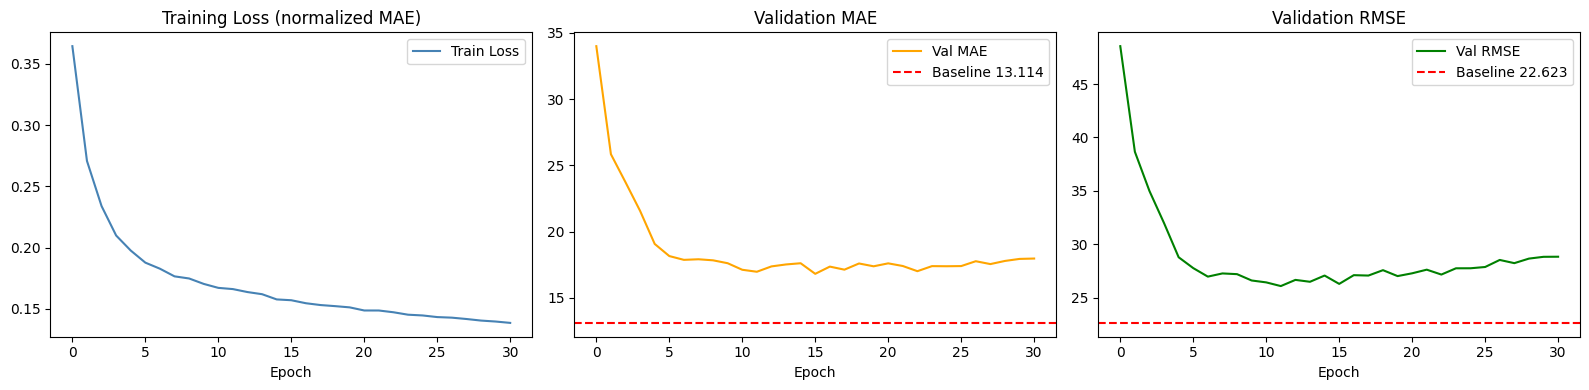

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['train_loss'], color='steelblue', label='Train Loss')
axes[0].set_title('Training Loss (normalized MAE)'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['val_mae'], color='orange', label='Val MAE')
axes[1].axhline(13.114, color='red', ls='--', label='Baseline 13.114')
axes[1].set_title('Validation MAE'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['val_rmse'], color='green', label='Val RMSE')
axes[2].axhline(22.623, color='red', ls='--', label='Baseline 22.623')
axes[2].set_title('Validation RMSE'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig('training_curves_phase2.png', dpi=150)
plt.show()

In [13]:
model.load_state_dict(torch.load('best_mdgrtn_phase2.pt', map_location=device))
test_mae, test_rmse, test_mape = eval_epoch(model, dl_test, A_dist, device, mean_flow, std_flow)

print('\n' + '='*60)
print(f'  Test MAE  : {test_mae:.3f}    baseline: 13.114   delta: {test_mae-13.114:+.3f}')
print(f'  Test RMSE : {test_rmse:.3f}   baseline: 22.623   delta: {test_rmse-22.623:+.3f}')
print(f'  Test MAPE : {test_mape:.2f}%   baseline:  8.471%  delta: {test_mape-8.471:+.2f}%')
print('='*60)


  Test MAE  : 15.652    baseline: 13.114   delta: +2.538
  Test RMSE : 23.269   baseline: 22.623   delta: +0.646
  Test MAPE : 6906.84%   baseline:  8.471%  delta: +6898.37%


In [14]:
# ── Per-prediction-horizon metrics (3, 6, 12 steps ahead) ──
@torch.no_grad()
def horizon_metrics(model, loader, A_dist, device, mean_flow, std_flow, horizons=(2,5,11)):
    model.eval()
    results = {h:{'mae':[],'rmse':[],'mape':[]} for h in horizons}
    for x_rec, x_day, x_week, y in loader:
        x_rec, x_day, x_week, y = (t.to(device) for t in (x_rec, x_day, x_week, y))
        pred   = model(x_rec, x_day, x_week, A_dist)
        pred_d = pred * std_flow[None,None,:] + mean_flow[None,None,:]
        y_d    = y    * std_flow[None,None,:] + mean_flow[None,None,:]
        for h in horizons:
            p_h = pred_d[:, h, :]
            y_h = y_d[:, h, :]
            results[h]['mae'].append(masked_mae(p_h, y_h).item())
            results[h]['rmse'].append(masked_rmse(p_h, y_h).item())
            results[h]['mape'].append(masked_mape(p_h, y_h).item())
    return {h: {k: np.mean(v) for k,v in m.items()} for h, m in results.items()}

hor = horizon_metrics(model, dl_test, A_dist, device, mean_flow, std_flow)
print(f'{"Horizon":>10} | {"MAE":>8} | {"RMSE":>8} | {"MAPE":>8}')
print('-'*42)
for step, label in zip((2,5,11), ('3-step (15min)', '6-step (30min)', '12-step (60min)')):
    m = hor[step]
    print(f'{label:>14} | {m["mae"]:>8.3f} | {m["rmse"]:>8.3f} | {m["mape"]:>7.2f}%')

   Horizon |      MAE |     RMSE |     MAPE
------------------------------------------
3-step (15min) |   14.536 |   21.397 | 6469.53%
6-step (30min) |   15.602 |   23.154 | 6670.91%
12-step (60min) |   17.406 |   25.803 | 6912.88%


## Architecture Summary

```
Input: x_recent, x_yesterday, x_week  each (B, 12, 170, 3)
           ↓           ↓           ↓
        BackNet₁    BackNet₂    BackNet₃    ← MLP denoisers (backward process)
           └───────── MAF ──────────┘       ← multi-head attn over nodes per period
                       ↓
                  (B, 12, 170, 128)
                       ↓
        MGRC: A_dyna + A_dist → Conv → A_F
              ChebGCN(K=2) + GRU × 4 layers
                       ↓
              Spatial Transformer × 4  (attn over 170 nodes)
                       ↓
              Temporal Transformer × 4 (attn over 12 steps)
                       ↓
              LayerNorm → Linear(128×12 → 256 → 12)
                       ↓
             Output: (B, 12, 170)  — predicted flow
```

**Key differences from Phase 1:**
- 3 BackNet denoisers (one per period) instead of 1
- Per-sensor z-score normalisation (not global)
- ChebGCN (K=2) instead of plain GCN
- Separate src/tgt embeddings for dynamic adjacency
- 4 Spatial + 4 Temporal Transformer layers (up from 2)
- AdamW + Cosine LR schedule
- Deeper output head with GELU